# Debugging Notebook for functions

In [8]:
%reload_ext autoreload
%autoreload 2

In [9]:
from encoding import *
from processing import *
from decoding import *
from visualize import *
from trainer import *
from mesh import *
#from main import *
import numpy as np
import matplotlib.pyplot as plt

# Loading data from mnist set
Functions in encoding.py

1
Number of '7' in this set: 54, number of '1' in this set: 56


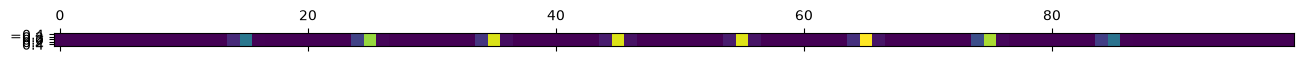

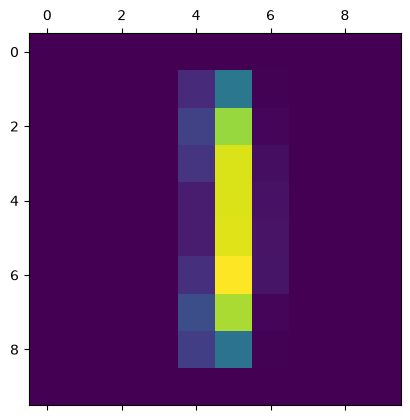

In [10]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = 110 #Sets number of samples you want to get in total
m_side = 10 #side length (pixel) of mnist image after downsampling
theta = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = True #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration

E_X, Y = get_data(values, mode, number, m_side, theta, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels
#Example of the first entry
plt.matshow(np.real(E_X[:,0]).reshape(1, -1), ) #reshaping it just for plotting with plt.matshow
plt.matshow(np.real(E_X[:,0]).reshape(m_side,m_side))
print(Y[0])

print("Number of '7' in this set: " + str(np.sum(Y == 7))+", number of '1' in this set: " + str(np.sum(Y == 1)))


# Initializing MZI-Mesh
Functions in mesh.py
(No parameter initialization yet)

Number of layers in the setup: 4
MZIs along the layers in the setup: [2, 1, 2, 1]
Total number of (trainable) MZIs in the setup: 6


<Axes: title={'center': 'N=4, 4 Layer, 6 MZIs'}, xlabel='Layer', ylabel='Channel'>

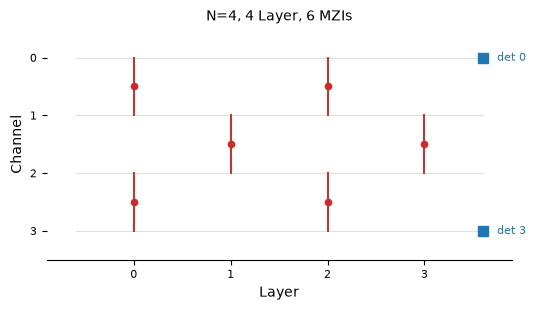

In [11]:
N=4 #Number of channels
L=4 #Number of layers
test_plan = plan_rectangular(N, L) #other plans are plan_redundant and plan_triangular
test_mesh = MZIMesh(N, test_plan) #Object containing the geometry of the MZI-Mesh

#Each mesh object carries its properties:
n_layers = test_mesh.n_layers
n_slots = test_mesh.slot_counts
n_mzis = test_mesh.n_mzis
print(f"Number of layers in the setup: {n_layers}") #layers of setup
print(f"MZIs along the layers in the setup: {n_slots}") #distribution of MZIs along the layers
print(f"Total number of (trainable) MZIs in the setup: {n_mzis}") #number of (trainable MZIs in this setup)


plot_mesh(test_mesh, color_by=None, detectors=[0, 3], label_step=None) #function of visualize.py to show the geometry (and detectors)


# Initializing Mesh parameters
Functions in mesh.py, here just init_random, also init_haar already coded (later used)

Phis: [array([1.71854477, 0.60281997]), array([3.0336238]), array([2.28645629, 0.25990208]), array([3.13944865])]
Thetas: [array([1.68002462, 0.96989562]), array([0.72234874]), array([1.15211739, 1.08766451]), array([1.54843705])]


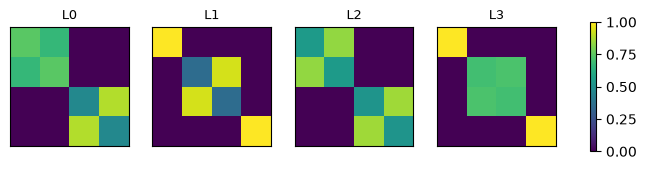

In [12]:
thetas, phis = test_mesh.init_random()
print(f"Phis: {phis}")
print(f"Thetas: {thetas}")

layers = test_mesh.layer_matrices(thetas, phis)   #building layers (transfer matrices) out of the parameters
fig, _ = plot_layers(layers, mode="Abs")


# Propagation

[[-0.06931034-0.00906408j -0.05799717-0.0064704j  -0.02787381-0.03508666j
  ... -0.02740203-0.02439554j -0.03130652-0.04198773j
  -0.02724835-0.04196944j]
 [-0.02370712-0.00343837j -0.01951532-0.00660349j  0.02184471-0.02940899j
  ... -0.00959595-0.02142726j  0.00335601-0.0307606j
   0.02158783-0.03813998j]
 [ 0.03016977-0.02714709j  0.02498237-0.02626567j  0.01441234+0.00823017j
  ...  0.01638094-0.01525944j  0.01965909-0.00565869j
   0.01952963+0.0101037j ]
 ...
 [ 0.00996545-0.02473253j  0.01285131-0.03894433j  0.01417841-0.11493261j
  ...  0.00984221-0.03850655j -0.00075197+0.00924073j
   0.00150546-0.04599122j]
 [-0.01543317+0.01138596j -0.02353791+0.02254699j -0.05707546+0.0213055j
  ... -0.03641637+0.05429848j -0.00735714-0.03989341j
  -0.11389232-0.00738046j]
 [-0.03743598-0.04430115j -0.05873518-0.06879015j -0.01000122-0.02200541j
  ... -0.06534292-0.07950976j  0.04632593+0.05237212j
   0.00816746-0.03540629j]]
(100, 110)
[[[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00

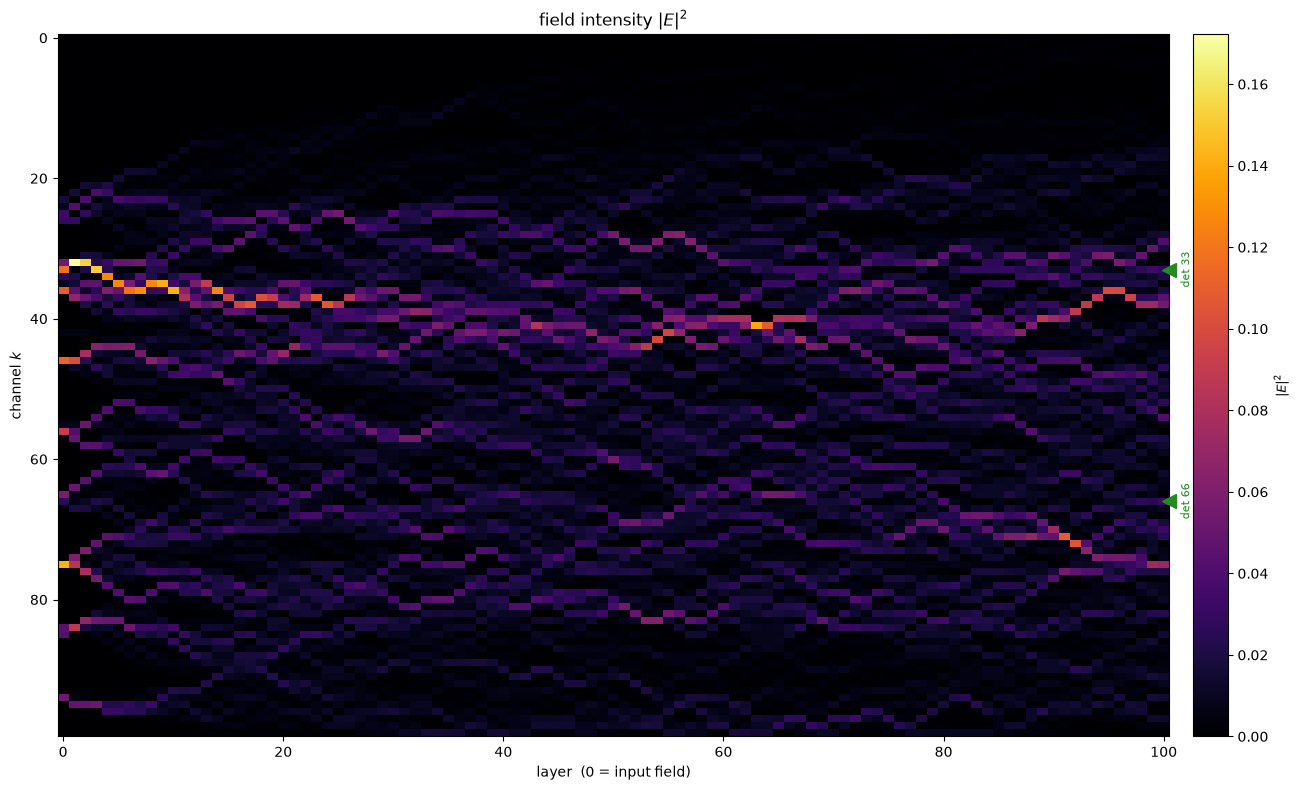

In [13]:
N=100 #number of channels (number of pixels in mnist image)
prop_mesh = MZIMesh(N, plan_rectangular(N, N)) #creating mesh object
thetas, phis = prop_mesh.init_random() #initializing random weights

layers = prop_mesh.layer_matrices(thetas, phis)   #build transfer matrices (layers) from parameters

E_out  = forward(E_X, layers)         #propagation that gives end result directly
print(E_out)                          #format: [channels, batches]
print(np.shape(E_out))

E_hist = forward_history(E_X, layers) #propagation that gives all E-fields for every layer
print(E_hist)                         #format: [layers, channels, batches]
I = np.abs(E_hist[:,:,2])**2
fig, _ = plot_intensity_map(I, detectors=[33,66])

[]

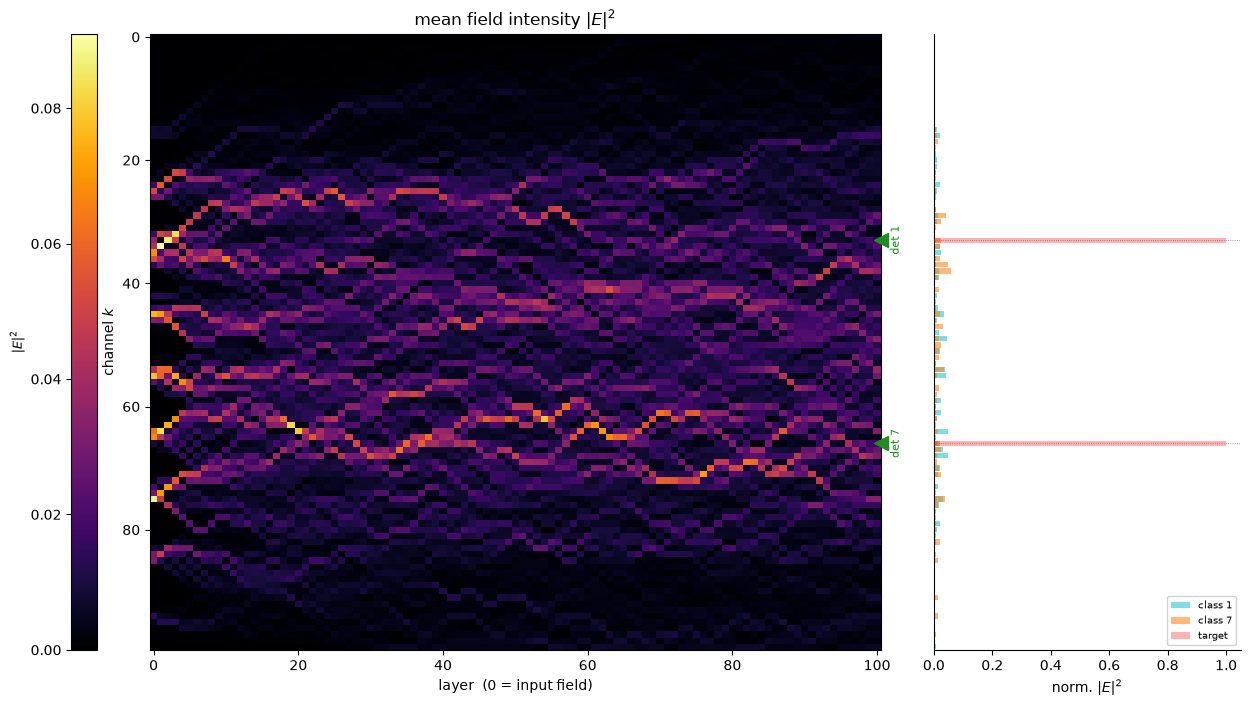

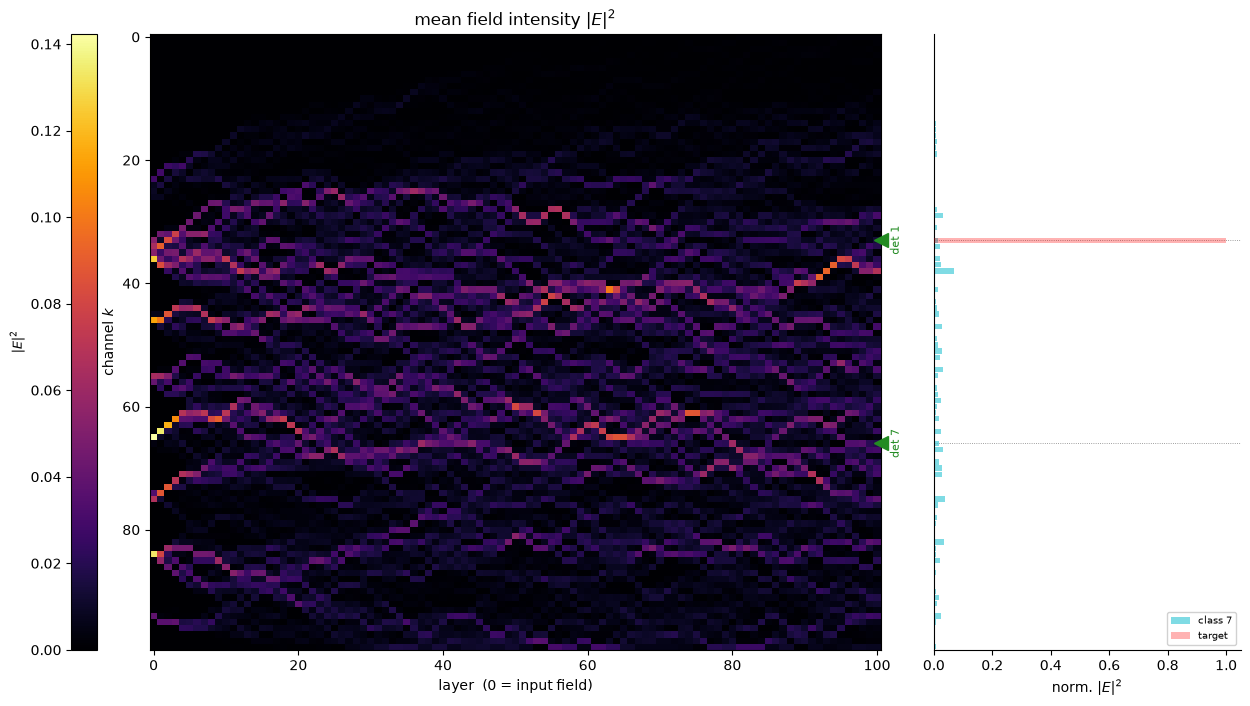

In [14]:
fig, _ = plot_intensity_map_with_histogram(np.abs(E_hist[:,:,1:10])**2, det1=33, det7=66, Y=Y[1:10])
plt.plot()
fig, _ = plot_intensity_map_with_histogram(np.abs(E_hist[:,:,36])**2, det1=33, det7=66, Y=Y[36])
plt.plot()

In [15]:
loss_norm=loss_function(E_hist, Y, 33, 66, kind="mse_norm" )
loss=loss_function(E_hist, Y, 33, 66, kind="mse" )

#plt.plot(loss[1])
#print(np.argmin(loss_norm[1], axis=1))
#print(np.argmin(loss[1], axis=1))
#print(np.shape(loss[1]))
#print(loss[1][:,1])
#print(loss[0])


# Linear regression
with vs. without normalized energy

In [16]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = None #Sets number of samples you want to get in total
m = 10 #side length (pixel) of mnist image after downsampling
theta = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = False #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration

E_X_Train, Y_Train = get_data(values, "Training", number, m, theta, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels

E_X_Test, Y_Test = get_data(values, "Testing", number, m, theta, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels

theta, y_predict, accuracy = linear_regression(E_X_Train.T, Y_Train, E_X_Test.T, Y_Test)
print(accuracy)

NameError: name 'linear_regression' is not defined

In [ ]:
print(np.shape(E_X_Train))
mask7 = Y_Train==7
mask1 = Y_Train==1
print(np.mean(np.abs(E_X_Train[:,mask7])**2, axis=0))
print(np.mean(np.abs(E_X_Train[:,mask1])**2, axis=0))


(100, 13007)
[0.01 0.01 0.01 ... 0.01 0.01 0.01]
[0.01 0.01 0.01 ... 0.01 0.01 0.01]


In [ ]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = None #Sets number of samples you want to get in total
m = 10 #side length (pixel) of mnist image after downsampling
theta = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = True #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration

E_X_Train, Y_Train = get_data(values, "Training", number, m, theta, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels

E_X_Test, Y_Test = get_data(values, "Testing", number, m, theta, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels

theta, y_predict, accuracy = linear_regression(E_X_Train.T, Y_Train, E_X_Test.T, Y_Test)
print(accuracy)

[[1133    2]
 [  14 1014]]
0.9926028663892742


## Plotting intensity-differences between 7 and 1

In [ ]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = None #Sets number of samples you want to get in total
m = 10 #side length (pixel) of mnist image after downsampling
theta = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = False #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration

E_X_Train, Y_Train = get_data(values, "Training", number, m, theta, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels

E_X_Test, Y_Test = get_data(values, "Testing", number, m, theta, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels


(100, 13007)


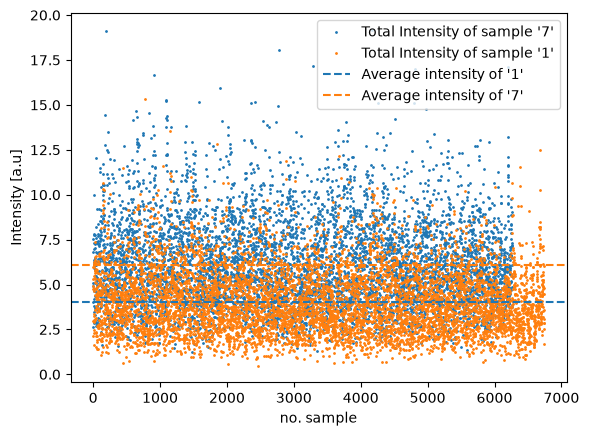

In [ ]:
print(np.shape(E_X_Train))
mask7 = Y_Train==7
mask1 = Y_Train==1

sumIntensity7 = np.sum(np.abs(E_X_Train[:,mask7])**2, axis=0)
sumIntensity1 = np.sum(np.abs(E_X_Train[:,mask1])**2, axis=0)
avgIntensity7 = np.mean(sumIntensity7)
avgIntensity1 = np.mean(sumIntensity1)
plt.plot(sumIntensity7, color="tab:blue", label="Total Intensity of sample '7'", linewidth=0.0, marker="o", markersize=1)
plt.plot(sumIntensity1, color="tab:orange", label="Total Intensity of sample '1'", linewidth=0.0, marker="o", markersize=1)
plt.axhline(y=avgIntensity1, color="tab:blue", linestyle="--", label="Average intensity of '1'")
plt.axhline(y=avgIntensity7, color="tab:orange", linestyle="--", label="Average intensity of '7'")
plt.ylabel("Intensity [a.u]")
plt.xlabel("no. sample")
plt.legend()

# O